In [1]:
# 1. 导入必要的库
import time
import numpy as np
import matplotlib.pyplot as plt
from pyfmi import load_fmu
import logging

import time
import pytz
from datetime import datetime

import sys
sys.path.append('rtfmu_simulatorV1_91http_Pro.py')  # 替换为你的模块路径
# 导入RTFmuSimulator类
from rtfmu_simulatorV1_91http_Pro import RTFmuSimulator

# 设置日志级别
# logging.basicConfig(level=logging.INFO)

In [2]:
# 设置你的时区
shanghai_tz = pytz.timezone('Asia/Shanghai')  # 例如，设置为上海时区
 
# 获取当前时间并转换为你的时区
now_in_local_tz = datetime.now(tz=shanghai_tz)
print("当前时间（上海时区）:", now_in_local_tz)
seconds_since_epoch = now_in_local_tz.timestamp()
print("当前:",seconds_since_epoch,"s")

# 获取今年的第一天
first_day_of_year = datetime(now_in_local_tz.year, 1, 1)
seconds_first_day_of_year=first_day_of_year.timestamp()
 
# 计算当前时间与今年第一天之间的总秒数
seconds_since_start_of_year = seconds_since_epoch-seconds_first_day_of_year
 
# 输出结果
print(f"当前时间是今年的第 {int(seconds_since_start_of_year)} 秒")

utc_time=datetime.fromtimestamp(seconds_since_start_of_year+seconds_first_day_of_year)
shanghai_time = utc_time.replace(tzinfo=pytz.utc).astimezone(shanghai_tz)
print("当前时间（上海时区）:",shanghai_time)

# 2. 创建并初始化仿真器
simulator = RTFmuSimulator('DataCenter_Test.fmu', step_size=60.0, real_time_factor=1.0)
# 初始化，设置监控和可修改变量
simulator.initialize(start_time=seconds_since_start_of_year, 
    variables=['roo.TRooAir', 'weaBus.TWetBul'], 
    modifiable_variables=['valCon51.k']
)

当前时间（上海时区）: 2025-11-24 16:05:07.795859+08:00
当前: 1763971507.795859 s
当前时间是今年的第 28281907 秒
当前时间（上海时区）: 2025-11-24 16:05:07.795859+08:00
已加载模型: Buildings.DataCenter_Test
✓ 模型支持FMU状态获取/设置
监控变量: TAirSup.port_b.h_outflow, TCHWLeaCoi.port_a.h_outflow, TCHWLeaCoi.port_b.h_outflow, TCWLeaTow.port_a.h_outflow, TCWLeaTow.port_b.h_outflow, chi.preDro2.port_b.h_outflow, cooCoi.port_a1.h_outflow, cooCoi.port_a2.h_outflow, cooCoi.port_b1.h_outflow, cooCoi.port_b2.h_outflow


2025-11-24 08:05:08,043 - RTFmuSimulator - INFO - 模型已初始化，起始时间: 28281907.7958591


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


True

In [3]:
# 3. 启动HTTP服务器
success = simulator.start_http_server(host="0.0.0.0", port=5000)
print(f"HTTP服务器启动状态: {success}")

INFO:FMU_HTTP_Server:客户端HTML文件已创建: /home/jovyan/work/FMU/DataCenter_Testa273/client/fmu_client_Pro.html


 * Serving Flask app 'FMU_HTTP_Server'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.18.0.8:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:FMU_HTTP_Server:HTTP服务器已启动: http://0.0.0.0:5000
2025-11-24 08:05:34,357 - RTFmuSimulator - INFO - HTTP服务器已启动: http://0.0.0.0:5000
INFO:RTFmuSimulator:HTTP服务器已启动: http://0.0.0.0:5000


HTTP服务器启动状态: True


In [4]:
# 4. 打印访问URL
print("请在浏览器中访问以下URL来控制仿真:")
print("http://localhost:5000/")

请在浏览器中访问以下URL来控制仿真:
http://localhost:5000/


In [ ]:
# 5. 保持服务器运行
print("服务器将在后台运行，按Ctrl+C或中断单元格执行来停止服务器")
# 可选：执行一些初始化操作
simulator.set_step_size(60)  # 设置步长为0.1秒
simulator.set_variable("valCon51.k", 281.15)  # 设置输入变量的初始值
# 可选：启动仿真
simulator.start_realtime()

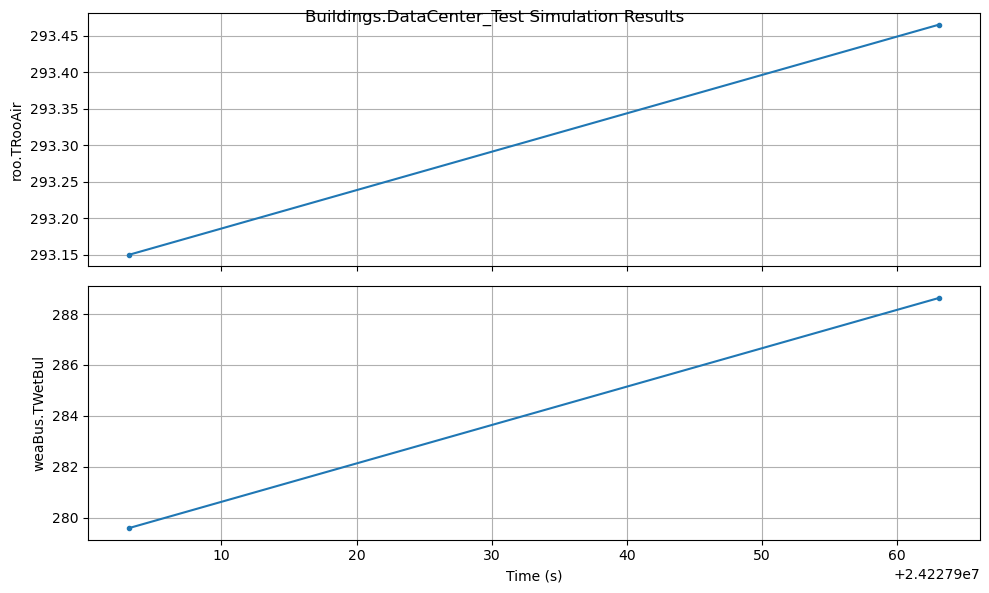

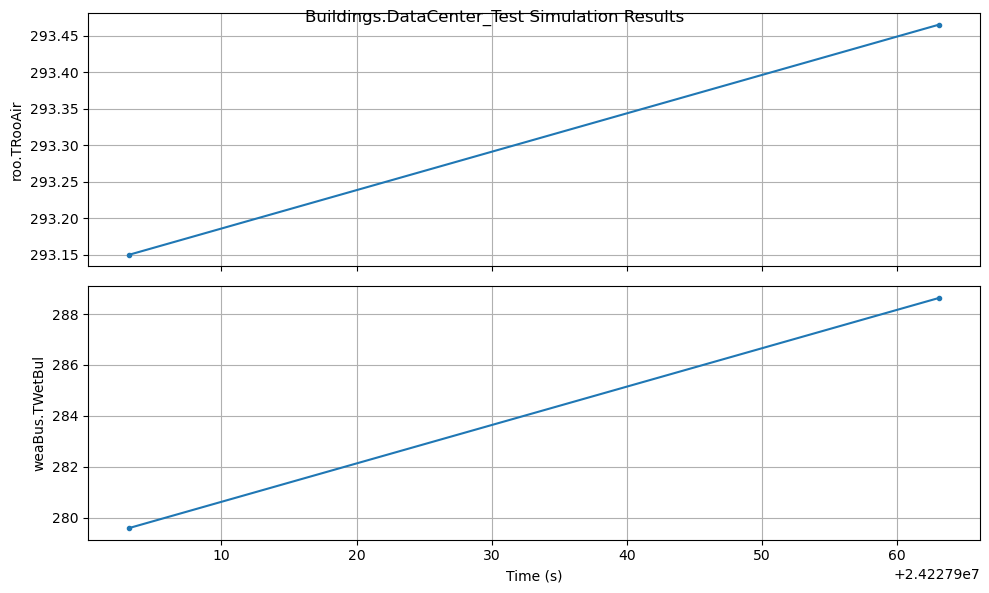

In [6]:
simulator.plot_results()


In [ ]:
# 保持单元格运行，直到手动中断
try:
    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("正在停止服务器...")
    simulator.stop_http_server()
    print("服务器已停止")

In [ ]:
import subprocess
 
# 查看 IP 地址
ip_address = subprocess.check_output(['hostname', '-I']).decode('utf-8').strip()
print(f"IP Address: {ip_address}")
 
# 查看路由表（可能需要安装 net-tools 或 iproute2）
route_output = subprocess.check_output(['route', '-n']).decode('utf-8')
print("Route Table:")
print(route_output)

In [ ]:
echo $'alias docker-om=\'docker run -it -v $HOME:$HOME -v /tmp/.X11-unix:/tmp/.X11-unix -e HOME=$HOME -w $PWD -e DISPLAY=$DISPLAY --name=MyOpenModelica openmodelica/openmodelica:v1.25.0-gui\'' >> $HOME/.profile



MyOpenModelica
docker exec -u 0 -it 0d442de06315 bash
JetAgxOpenModelica
docker exec -u 0 -it 046df78fcd90 bash


sudo setfacl -d -m o::rx ./OmWorkspace


sudo chmod -R 777 ./OmWorkspace
sudo cp ./OmWorkspace/DataCenter_Exch.fmu /var/lib/docker/volumes/MyJupyter/_data/FMU/DataCenter_Testa273


Buildings.Examples.ScalableBenchmarks.BuildingVAV.Examples.OneFloor_OneZone

TCHWSet ChillerParallel.Tset
TAirSupSet TSupAirSet ahuValSig.u_s/ahu.Tset
TAirRetSet TRetAirSet

In [ ]:
model DataCenter_Solo
  import Buildings.Examples.ChillerPlant.BaseClasses;
  replaceable package MediumA = Buildings.Media.Air "Medium model";
  replaceable package MediumW = Buildings.Media.Water "Medium model";
  //====================== 系统参数 ======================//
  parameter Modelica.Units.SI.MassFlowRate mAir_flow_nominal = roo.QRoo_flow/(1005*15) "Nominal mass flow rate at fan";
  parameter Modelica.Units.SI.Power P_nominal = 80E3 "Nominal compressor power (at y=1)";
  parameter Modelica.Units.SI.TemperatureDifference dTEva_nominal = 10 "Temperature difference evaporator inlet-outlet";
  parameter Modelica.Units.SI.TemperatureDifference dTCon_nominal = 10 "Temperature difference condenser outlet-inlet";
  parameter Real COPc_nominal = 3 "Chiller COP";
  parameter Modelica.Units.SI.MassFlowRate mCHW_flow_nominal = 2*roo.QRoo_flow/(4200*20) "Nominal mass flow rate at chilled water";
  parameter Modelica.Units.SI.MassFlowRate mCW_flow_nominal = 2*roo.QRoo_flow/(4200*6) "Nominal mass flow rate at condenser water";
  parameter Modelica.Units.SI.PressureDifference dp_nominal = 500 "Nominal pressure difference";
  //====================== 设备声明 ======================//
  //---------------------- 冷却侧 ----------------------
  // 设备：冷却塔
  Buildings.Fluid.HeatExchangers.CoolingTowers.YorkCalc cooTow(redeclare package Medium = MediumW, m_flow_nominal = mCW_flow_nominal, PFan_nominal = 6000, TAirInWB_nominal(displayUnit = "degC") = 283.15, TApp_nominal = 6, dp_nominal = 14930 + 14930 + 74650, energyDynamics = Modelica.Fluid.Types.Dynamics.FixedInitial) "Cooling tower" annotation(
    Placement(transformation(extent = {{-10, -10}, {10, 10}}, origin = {269, 239})));
  // 设备：冷却泵
  Buildings.Fluid.Movers.FlowControlled_m_flow pumCW(redeclare package Medium = MediumW, m_flow_nominal = mCW_flow_nominal, dp(start = 214992), nominalValuesDefineDefaultPressureCurve = true, use_riseTime = false, energyDynamics = Modelica.Fluid.Types.Dynamics.FixedInitial, dp_nominal = 130000, inputType = Buildings.Fluid.Types.InputType.Continuous) "Condenser water pump" annotation(
    Placement(transformation(extent = {{-10, 10}, {10, -10}}, rotation = 270, origin = {358, 200})));
  // 设备：膨胀水箱；冷却环路
  Buildings.Fluid.Storage.ExpansionVessel expVesChi(redeclare package Medium = MediumW, V_start = 1) "Expansion vessel" annotation(
    Placement(transformation(origin = {-76, -18}, extent = {{236, 143}, {256, 163}})));
  // 阀：两通线性阀；冷却水-干管-出主机
  Buildings.Fluid.Actuators.Valves.TwoWayLinear val5(redeclare package Medium = MediumW, m_flow_nominal = mCW_flow_nominal, dpValve_nominal = 20902, dpFixed_nominal = 89580, y_start = 1, use_strokeTime = false) "Control valve for condenser water loop of chiller" annotation(
    Placement(transformation(extent = {{-10, -10}, {10, 10}}, rotation = 90, origin = {218, 180})));
  //---------------------- 冷冻侧 ----------------------
  // 设备：冷水机组：水冷离心式冷水机组
  Buildings.Fluid.Chillers.ElectricEIR chi(redeclare package Medium1 = MediumW, redeclare package Medium2 = MediumW, m1_flow_nominal = mCW_flow_nominal, m2_flow_nominal = mCHW_flow_nominal, dp2_nominal = 0, dp1_nominal = 0,  // TSet.y=TSetpoint,
  per = Buildings.Fluid.Chillers.Data.ElectricEIR.ElectricEIRChiller_Carrier_19XR_742kW_5_42COP_VSD(), energyDynamics = Modelica.Fluid.Types.Dynamics.FixedInitial) "Chiller" annotation(
    Placement(transformation(extent = {{274, 83}, {254, 103}})));
  // 设备：泵；冷冻泵
  Buildings.Fluid.Movers.FlowControlled_dp pumCHW(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal, m_flow(start = mCHW_flow_nominal), dp(start = 325474), nominalValuesDefineDefaultPressureCurve = true, use_riseTime = false, energyDynamics = Modelica.Fluid.Types.Dynamics.FixedInitial, dp_nominal = 130000) "Chilled water pump" annotation(
    Placement(transformation(extent = {{10, 10}, {-10, -10}}, rotation = 270, origin = {218, -120})));
  // 设备：膨胀水箱；冷冻环路
  Buildings.Fluid.Storage.ExpansionVessel expVesCHW(redeclare package Medium = MediumW, V_start = 1) "Expansion vessel" annotation(
    Placement(transformation(origin = {8, 2}, extent = {{248, -147}, {268, -127}})));
  // 阀：两通线性阀；冷冻水-干管-回主机
  Buildings.Fluid.Actuators.Valves.TwoWayLinear val6(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal, dpValve_nominal = 20902, dpFixed_nominal = 14930 + 89580, y_start = 1, use_strokeTime = false, from_dp = true) "Control valve for chilled water leaving from chiller" annotation(
    Placement(transformation(extent = {{-10, 10}, {10, -10}}, rotation = 270, origin = {358, 40})));
  // 阀：等百分比调节阀；旁通调节阀
  Buildings.Fluid.Actuators.Valves.TwoWayEqualPercentage valByp(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal, dpValve_nominal = 20902, dpFixed_nominal = 14930, y_start = 0, use_strokeTime = false, from_dp = true) "Bypass valve for chiller" annotation(
    Placement(transformation(extent = {{-10, -10}, {10, 10}}, origin = {288, 20})));
  //---------------------- 用户侧 ----------------------
  // 设备：风机；AHU风机
  Buildings.Fluid.Movers.FlowControlled_m_flow fan(redeclare package Medium = MediumA, m_flow_nominal = mAir_flow_nominal, dp(start = 249), m_flow(start = mAir_flow_nominal), nominalValuesDefineDefaultPressureCurve = true, use_riseTime = false, energyDynamics = Modelica.Fluid.Types.Dynamics.SteadyState, dp_nominal = 750) "Fan for air flow through the data center" annotation(
    Placement(transformation(extent = {{348, -235}, {328, -215}})));
  // 设备：干盘管；AHU盘管
  Buildings.Fluid.HeatExchangers.DryCoilCounterFlow cooCoi(redeclare package Medium1 = MediumW, redeclare package Medium2 = MediumA, UA_nominal = mAir_flow_nominal*1006*5, dp1_nominal(displayUnit = "Pa") = 1000 + 89580, dp2_nominal = 249*3, energyDynamics = Modelica.Fluid.Types.Dynamics.FixedInitial, m1_flow(start = mCHW_flow_nominal), m1_flow_nominal = mCHW_flow_nominal, m2_flow(start = mAir_flow_nominal), m2_flow_nominal = mAir_flow_nominal) annotation(
    Placement(transformation(origin = {6, 16}, extent = {{300, -180}, {280, -160}})));
  // 阀：两通线性阀；冷冻水-支管-出末端
  Buildings.Fluid.Actuators.Valves.TwoWayLinear val1(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal, dpValve_nominal = 20902, use_strokeTime = false) "Control valve for chilled water loop of AHU" annotation(
    Placement(transformation(extent = {{-10, -10}, {10, 10}}, rotation = 90, origin = {218, -40})));
  //---------------------- 房间 ----------------------
  // 房间：简化房间
  BaseClasses.SimplifiedRoom roo(redeclare package Medium = MediumA, nPorts = 2, rooLen = 50, rooWid = 30, rooHei = 3, m_flow_nominal = mAir_flow_nominal, QRoo_flow = 50000) "Room model" annotation(
    Placement(transformation(origin = {248, -238}, extent = {{-10, 10}, {10, -10}})));
  //====================== 数据采集 ======================//
  // 传感器:温度；风-送风
  Buildings.Fluid.Sensors.TemperatureTwoPort TAirSup(redeclare package Medium = MediumA, m_flow_nominal = mAir_flow_nominal) "Supply air temperature to data center" annotation(
    Placement(transformation(extent = {{10, -10}, {-10, 10}}, origin = {288, -225})));
  // 传感器:温度-冷冻水-干管-回主机
  Buildings.Fluid.Sensors.TemperatureTwoPort TCHWEntChi(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal) "Temperature of chilled water entering chiller" annotation(
    Placement(transformation(extent = {{10, 10}, {-10, -10}}, rotation = 270, origin = {218, 0})));
  // 传感器:温度；冷却水-干管-出冷却塔
  Buildings.Fluid.Sensors.TemperatureTwoPort TCWLeaTow(redeclare package Medium = MediumW, m_flow_nominal = mCW_flow_nominal) "Temperature of condenser water leaving the cooling tower" annotation(
    Placement(transformation(extent = {{10, -10}, {-10, 10}}, origin = {330, 119})));
  // 传感器:温度；冷冻水-干管-末端出
  Buildings.Fluid.Sensors.TemperatureTwoPort TCHWLeaCoi(redeclare package Medium = MediumW, m_flow_nominal = mCHW_flow_nominal) "Temperature of chilled water leaving the cooling coil" annotation(
    Placement(transformation(extent = {{10, 10}, {-10, -10}}, rotation = 270, origin = {218, -80})));
  //====================== 边界条件 ======================//
  // 数据读取：气象文件
  Buildings.BoundaryConditions.WeatherData.ReaderTMY3 weaData(filNam = "CHN_Hong.Kong.SAR.450070_CityUHK.mos") "Read weather" annotation(
    Placement(transformation(origin = {356, 332}, extent = {{-360, -100}, {-340, -80}})));
  // 边界条件：气象
  Buildings.BoundaryConditions.WeatherData.Bus weaBus "Weather conditions" annotation(
    Placement(transformation(origin = {356, 332}, extent = {{-332, -98}, {-312, -78}}), iconTransformation(extent = {{-332, -98}, {-312, -78}})));
  // 数据读取：建筑参数
  //====================== 控制输入 ======================//
  // 优化设定点；主机冷冻出水温度
  // 常数：正实数；流量-送风机
  Modelica.Blocks.Sources.Constant mFanFlo(k = mAir_flow_nominal) "Mass flow rate of fan" annotation(
    Placement(transformation(origin = {2, 16}, extent = {{298, -210}, {318, -190}})));
  // 常数：0-1；控制信号-风机-冷却塔
  Modelica.Blocks.Sources.Constant cooTowFanCon(k = 1) "Control singal for cooling tower fan" annotation(
    Placement(transformation(origin = {190, 271}, extent = {{-10, -10}, {10, 10}})));
  //====================== 数据处理 ======================//
  // 运算：常规运算；HVAC功率
  Modelica.Blocks.Sources.RealExpression PHVAC(y = fan.P + pumCHW.P + pumCW.P + cooTow.PFan + chi.P) "Power consumed by HVAC system" annotation(
    Placement(transformation(origin = {266, -52}, extent = {{-10, -10}, {10, 10}})));
  // 运算：常规运算；IT功率
  Modelica.Blocks.Sources.RealExpression PIT(y = roo.QSou.Q_flow) "Power consumed by IT" annotation(
    Placement(transformation(origin = {266, -82}, extent = {{-10, -10}, {10, 10}})));
  // 运算：积分；HVAC能耗
  Modelica.Blocks.Continuous.Integrator EHVAC(initType = Modelica.Blocks.Types.Init.InitialState, y_start = 0) "Energy consumed by HVAC" annotation(
    Placement(transformation(origin = {556, 198}, extent = {{-240, -260}, {-220, -240}})));
  // 运算：积分；IT能耗
  Modelica.Blocks.Continuous.Integrator EIT(initType = Modelica.Blocks.Types.Init.InitialState, y_start = 0) "Energy consumed by IT" annotation(
    Placement(transformation(origin = {556, 198}, extent = {{-240, -290}, {-220, -270}})));
  //====================== 常数 ======================//
  Modelica.Blocks.Sources.Constant valBypCon1(k = 0) annotation(
    Placement(transformation(origin = {246, 45}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Math.Gain gain(k = 20*6485) annotation(
    Placement(transformation(origin = {222, -220}, extent = {{-60, 90}, {-40, 110}})));
  Modelica.Blocks.Sources.Constant valCon11(k = 1) annotation(
    Placement(transformation(origin = {174, -41}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant valCon6(k = 1) annotation(
    Placement(transformation(origin = {320, 51}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant valCon5(k = 1) annotation(
    Placement(transformation(origin = {170, 179}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant pumCWCon1(k = 1) annotation(
    Placement(transformation(origin = {304, 199}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant pumCHWCon1(k = 1) annotation(
    Placement(transformation(origin = {118, -123}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant valCon51(k = 282.15) annotation(
    Placement(transformation(origin = {244, 141}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Math.RealToBoolean realToBoolean annotation(
    Placement(transformation(origin = {182, 70}, extent = {{-10, -10}, {10, 10}})));
  Modelica.Blocks.Sources.Constant chiCon1(k = 1) annotation(
    Placement(transformation(origin = {122, 69}, extent = {{-10, -10}, {10, 10}})));
  //====================== 连接 ======================//
equation
  connect(cooTow.port_b, pumCW.port_a) annotation(
    Line(points = {{279, 239}, {358, 239}, {358, 210}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(val5.port_a, chi.port_b1) annotation(
    Line(points = {{218, 170}, {218, 99}, {254, 99}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(expVesChi.port_a, chi.port_b1) annotation(
    Line(points = {{170, 125}, {201, 125}, {201, 99}, {254, 99}}, color = {0, 127, 255}, thickness = 0.5));
  connect(cooTowFanCon.y, cooTow.y) annotation(
    Line(points = {{201, 271}, {229.5, 271}, {229.5, 269}, {228, 269}, {228, 247}, {257, 247}}, color = {0, 0, 127}, pattern = LinePattern.Dash));
  connect(mFanFlo.y, fan.m_flow_in) annotation(
    Line(points = {{321, -184}, {338, -184}, {338, -213}}, color = {0, 0, 127}, pattern = LinePattern.Dash));
  connect(TAirSup.port_a, fan.port_b) annotation(
    Line(points = {{298, -225}, {328, -225}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(roo.airPorts[1], TAirSup.port_b) annotation(
    Line(points = {{247.438, -229.3}, {247.438, -225}, {278, -225}}, color = {0, 127, 255}, thickness = 0.5));
  connect(TCHWLeaCoi.port_a, pumCHW.port_b) annotation(
    Line(points = {{218, -90}, {218, -110}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(TCHWEntChi.port_b, valByp.port_a) annotation(
    Line(points = {{218, 10}, {218, 20}, {278, 20}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(TCHWEntChi.port_a, val1.port_b) annotation(
    Line(points = {{218, -10}, {218, -30}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(val1.port_a, TCHWLeaCoi.port_b) annotation(
    Line(points = {{218, -50}, {218, -70}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(TCWLeaTow.port_b, chi.port_a1) annotation(
    Line(points = {{320, 119}, {300, 119}, {300, 99}, {274, 99}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(weaData.weaBus, weaBus) annotation(
    Line(points = {{16, 242}, {25, 242}, {25, 244}, {34, 244}}, color = {255, 204, 51}, thickness = 0.5));
  connect(cooTow.TAir, weaBus.TWetBul) annotation(
    Line(points = {{257, 243}, {34, 243}, {34, 244}}, color = {0, 0, 127}, pattern = LinePattern.Dash));
  connect(valByp.port_b, val6.port_b) annotation(
    Line(points = {{298, 20}, {358, 20}, {358, 30}}, color = {0, 127, 255}, thickness = 0.5));
  connect(TCHWEntChi.port_b, chi.port_a2) annotation(
    Line(points = {{218, 10}, {218, 88}, {254, 88}, {254, 87}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(val5.port_b, cooTow.port_a) annotation(
    Line(points = {{218, 190}, {218, 239}, {259, 239}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(pumCW.port_b, TCWLeaTow.port_a) annotation(
    Line(points = {{358, 190}, {358, 119}, {340, 119}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(chi.port_b2, val6.port_a) annotation(
    Line(points = {{274, 87}, {358, 87}, {358, 50}}, color = {0, 127, 255}, smooth = Smooth.None, thickness = 0.5));
  connect(PHVAC.y, EHVAC.u) annotation(
    Line(points = {{277, -52}, {314, -52}}, color = {0, 0, 127}));
  connect(PIT.y, EIT.u) annotation(
    Line(points = {{277, -82}, {314, -82}}, color = {0, 0, 127}));
  connect(expVesCHW.port_a, pumCHW.port_a) annotation(
    Line(points = {{266, -145}, {218, -145}, {218, -130}}, color = {0, 127, 255}));
  connect(val6.port_b, cooCoi.port_a1) annotation(
    Line(points = {{358, 30}, {358, -148}, {306, -148}}, color = {0, 127, 255}));
  connect(cooCoi.port_b1, pumCHW.port_a) annotation(
    Line(points = {{286, -148}, {218, -148}, {218, -130}}, color = {0, 127, 255}));
  connect(roo.airPorts[2], cooCoi.port_a2) annotation(
    Line(points = {{248, -230}, {248, -212.5}, {230, -212.5}, {230, -225}, {218, -225}, {218, -160}, {286, -160}}, color = {0, 127, 255}));
  connect(cooCoi.port_b2, fan.port_a) annotation(
    Line(points = {{306, -160}, {348, -160}, {348, -224}}, color = {0, 127, 255}));
  connect(valBypCon1.y, valByp.y) annotation(
    Line(points = {{257, 45}, {288, 45}, {288, 32}}, color = {0, 0, 127}));
  connect(gain.y, pumCHW.dp_in) annotation(
    Line(points = {{183, -120}, {206, -120}}, color = {0, 0, 127}));
  connect(valCon11.y, val1.y) annotation(
    Line(points = {{186, -40}, {206, -40}}, color = {0, 0, 127}));
  connect(valCon6.y, val6.y) annotation(
    Line(points = {{331, 51}, {346, 51}, {346, 40}}, color = {0, 0, 127}));
  connect(valCon5.y, val5.y) annotation(
    Line(points = {{182, 180}, {206, 180}}, color = {0, 0, 127}));
  connect(pumCWCon1.y, pumCW.m_flow_in) annotation(
    Line(points = {{316, 200}, {346, 200}}, color = {0, 0, 127}));
  connect(pumCHWCon1.y, gain.u) annotation(
    Line(points = {{130, -122}, {160, -122}, {160, -120}}, color = {0, 0, 127}));
  connect(chiCon1.y, realToBoolean.u) annotation(
    Line(points = {{134, 70}, {170, 70}}, color = {0, 0, 127}));
  connect(realToBoolean.y, chi.on) annotation(
    Line(points = {{194, 70}, {276, 70}, {276, 96}}, color = {255, 0, 255}));
//====================== 仿真设置 ======================//
  connect(valCon51.y, chi.TSet) annotation(
    Line(points = {{256, 142}, {256, 90}, {276, 90}}, color = {0, 0, 127}));
  annotation(
    Diagram(coordinateSystem(preserveAspectRatio = false, extent = {{-40, 300}, {380, -260}})),
    Documentation(info = "<HTML>
<p>
This model is the chilled water plant with discrete time control and
trim and respond logic for a data center. The model is described at
<a href=\"modelica://Buildings.Examples.ChillerPlant\">
Buildings.Examples.ChillerPlant</a>.
</p>
</html>", revisions = "<html>
<ul>
<li>
December 6, 2021, by Michael Wetter:<br/>
Changed initialization from steady-state initial to fixed initial.<br/>
This is for
<a href=\"https://github.com/lbl-srg/modelica-buildings/issues/2798\">issue 2798</a>.
</li>
<li>
November 18, 2021, by Michael Wetter:<br/>
Set <code>dp_nominal</code> for pumps and fan to a realistic value.<br/>
This is for
<a href=\"https://github.com/lbl-srg/modelica-buildings/issues/2761\">#2761</a>.
</li>
<li>
September 21, 2017, by Michael Wetter:<br/>
Set <code>from_dp = true</code> in <code>val6</code> and in <code>valByp</code>
which is needed for Dymola 2018FD01 beta 2 for
<a href=\"modelica://Buildings.Examples.ChillerPlant.DataCenterDiscreteTimeControl\">
Buildings.Examples.ChillerPlant.DataCenterDiscreteTimeControl</a>
to converge.
</li>
<li>
January 22, 2016, by Michael Wetter:<br/>
Corrected type declaration of pressure difference.
This is
for <a href=\"https://github.com/ibpsa/modelica-ibpsa/issues/404\">IBPSA, #404</a>.
</li>
<li>
January 13, 2015 by Michael Wetter:<br/>
Moved model to <code>BaseClasses</code> because the continuous and discrete time
implementation of the trim and respond logic do not extend from a common class,
and hence the <code>constrainedby</code> operator is not applicable.
Moving the model here allows to implement both controllers without using a
<code>replaceable</code> class.
</li>
<li>
January 12, 2015 by Michael Wetter:<br/>
Made media instances replaceable, and used the same instance for both
water loops.
This was done to simplify the numerical benchmarks.
</li>
<li>
December 22, 2014 by Michael Wetter:<br/>
Removed <code>Modelica.Fluid.System</code>
to address issue
<a href=\"https://github.com/lbl-srg/modelica-buildings/issues/311\">#311</a>.
</li>
<li>
March 25, 2014, by Michael Wetter:<br/>
Updated model with new expansion vessel.
</li>
<li>
December 5, 2012, by Michael Wetter:<br/>
Removed the filtered speed calculation for the valves to reduce computing time by 25%.
</li>
<li>
October 16, 2012, by Wangda Zuo:<br/>
Reimplemented the controls.
</li>
<li>
July 20, 2011, by Wangda Zuo:<br/>
Added comments and merge to library.
</li>
<li>
January 18, 2011, by Wangda Zuo:<br/>
First implementation.
</li>
</ul>
</html>"),
    version = "1.0",
    uses,
    experiment(StartTime = 0, StopTime = 86400, Tolerance = 1e-06, Interval = 60),
    __OpenModelica_commandLineOptions = "--matchingAlgorithm=PFPlusExt --indexReductionMethod=dynamicStateSelection --allowNonStandardModelica=reinitInAlgorithms -d=initialization,NLSanalyticJacobian",
    __OpenModelica_simulationFlags(lv = "LOG_STDOUT,LOG_ASSERT,LOG_STATS", s = "dassl", variableFilter = ".*"));
end DataCenter_Solo;